In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [3]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt
# train_test_split등을 추가

In [5]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [21]:
print('타겟변수 :', data[15,0])
image = data[15, 1:].reshape(28,28)
image.shape

타겟변수 : 7.0


(28, 28)

In [22]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()# 개행

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0115121162253253213  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 63107170251252252252252250214  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 25192226226241252253202252252252252252225  0  0  0  0  0  0
  0  0  0  0  0  0  0 68223252252252252252 39 19 39 65224252252183  0  0  0  0  0  0
  0  0  0  0  0  0  0186252252252245108 53  0  0  0150252252220 2

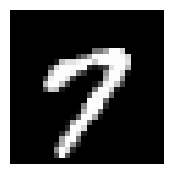

In [25]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# 칼라사진 -> 흑백모드로 넘파이배열로 읽기(pip install opencv-python==4.8.1.78)

In [ ]:
%pip install opencv-python==4.8.1.78

In [35]:
import cv2
# 사진이미지를 흑백포맷으로 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

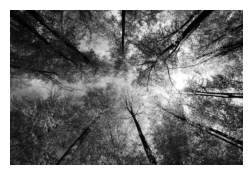

In [36]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

# 1. 데이터 생성 및 전처리

In [38]:
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [42]:
value, counts = np.unique(y_train, return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [44]:
value, counts = np.unique(y_test, return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

2


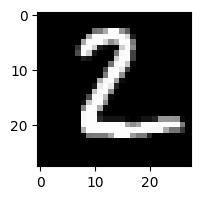

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [48]:
print(y_test[1])
plt.imshow(X_test[1], cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()

In [50]:
# Train데이터 6만개 => Train(5만개) + val(만개)로 분리
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [53]:
print('학습셋 :', X_train.shape, y_train.shape)
print('검증셋 :', X_val.shape, y_val.shape)
print('시험셋 :', X_test.shape, y_test.shape)

학습셋 : (50000, 28, 28) (50000,)
검증셋 : (10000, 28, 28) (10000,)
시험셋 : (10000, 28, 28) (10000,)


In [62]:
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [66]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [71]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# idx = random.sample(range(50000), 700)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]

In [73]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델 구성
# 3. 학습과정 설정

In [77]:
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 2)                 1570      
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_7 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습

In [78]:
%%time
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=100,
                epochs=200)

Epoch 1/200
7/7 [==============================] - 1s 28ms/step - loss: 2.3201 - accuracy: 0.1014 - val_loss: 2.2913 - val_accuracy: 0.1000
Epoch 2/200
7/7 [==============================] - 0s 4ms/step - loss: 2.2689 - accuracy: 0.1186 - val_loss: 2.2475 - val_accuracy: 0.1233
Epoch 3/200
7/7 [==============================] - 0s 5ms/step - loss: 2.2326 - accuracy: 0.1257 - val_loss: 2.2128 - val_accuracy: 0.1500
Epoch 4/200
7/7 [==============================] - 0s 4ms/step - loss: 2.2011 - accuracy: 0.1657 - val_loss: 2.1886 - val_accuracy: 0.1667
Epoch 5/200
7/7 [==============================] - 0s 5ms/step - loss: 2.1784 - accuracy: 0.2029 - val_loss: 2.1702 - val_accuracy: 0.1800
Epoch 6/200
7/7 [==============================] - 0s 5ms/step - loss: 2.1608 - accuracy: 0.2200 - val_loss: 2.1541 - val_accuracy: 0.1900
Epoch 7/200
7/7 [==============================] - 0s 5ms/step - loss: 2.1451 - accuracy: 0.2214 - val_loss: 2.1407 - val_accuracy: 0.2000
Epoch 8/200
7/7 [=========

7/7 [==============================] - 0s 4ms/step - loss: 1.6315 - accuracy: 0.3957 - val_loss: 1.6444 - val_accuracy: 0.3667
Epoch 60/200
7/7 [==============================] - 0s 5ms/step - loss: 1.6255 - accuracy: 0.4014 - val_loss: 1.6391 - val_accuracy: 0.3700
Epoch 61/200
7/7 [==============================] - 0s 4ms/step - loss: 1.6199 - accuracy: 0.4114 - val_loss: 1.6347 - val_accuracy: 0.3733
Epoch 62/200
7/7 [==============================] - 0s 4ms/step - loss: 1.6139 - accuracy: 0.4114 - val_loss: 1.6288 - val_accuracy: 0.3733
Epoch 63/200
7/7 [==============================] - 0s 5ms/step - loss: 1.6079 - accuracy: 0.4129 - val_loss: 1.6245 - val_accuracy: 0.3767
Epoch 64/200
7/7 [==============================] - 0s 5ms/step - loss: 1.6023 - accuracy: 0.4157 - val_loss: 1.6197 - val_accuracy: 0.3800
Epoch 65/200
7/7 [==============================] - 0s 5ms/step - loss: 1.5968 - accuracy: 0.4157 - val_loss: 1.6158 - val_accuracy: 0.3867
Epoch 66/200
7/7 [===============

7/7 [==============================] - 0s 5ms/step - loss: 1.3697 - accuracy: 0.4929 - val_loss: 1.4605 - val_accuracy: 0.4600
Epoch 118/200
7/7 [==============================] - 0s 5ms/step - loss: 1.3648 - accuracy: 0.4957 - val_loss: 1.4568 - val_accuracy: 0.4600
Epoch 119/200
7/7 [==============================] - 0s 5ms/step - loss: 1.3615 - accuracy: 0.4943 - val_loss: 1.4552 - val_accuracy: 0.4633
Epoch 120/200
7/7 [==============================] - 0s 4ms/step - loss: 1.3573 - accuracy: 0.4957 - val_loss: 1.4528 - val_accuracy: 0.4633
Epoch 121/200
7/7 [==============================] - 0s 5ms/step - loss: 1.3535 - accuracy: 0.4943 - val_loss: 1.4512 - val_accuracy: 0.4600
Epoch 122/200
7/7 [==============================] - 0s 4ms/step - loss: 1.3500 - accuracy: 0.4957 - val_loss: 1.4473 - val_accuracy: 0.4667
Epoch 123/200
7/7 [==============================] - 0s 4ms/step - loss: 1.3472 - accuracy: 0.4986 - val_loss: 1.4471 - val_accuracy: 0.4600
Epoch 124/200
7/7 [========

7/7 [==============================] - 0s 4ms/step - loss: 1.1960 - accuracy: 0.5271 - val_loss: 1.3841 - val_accuracy: 0.4800
Epoch 176/200
7/7 [==============================] - 0s 4ms/step - loss: 1.1938 - accuracy: 0.5271 - val_loss: 1.3847 - val_accuracy: 0.4800
Epoch 177/200
7/7 [==============================] - 0s 5ms/step - loss: 1.1914 - accuracy: 0.5286 - val_loss: 1.3842 - val_accuracy: 0.4800
Epoch 178/200
7/7 [==============================] - 0s 4ms/step - loss: 1.1897 - accuracy: 0.5329 - val_loss: 1.3831 - val_accuracy: 0.4800
Epoch 179/200
7/7 [==============================] - 0s 5ms/step - loss: 1.1873 - accuracy: 0.5314 - val_loss: 1.3839 - val_accuracy: 0.4833
Epoch 180/200
7/7 [==============================] - 0s 4ms/step - loss: 1.1851 - accuracy: 0.5329 - val_loss: 1.3842 - val_accuracy: 0.4833
Epoch 181/200
7/7 [==============================] - 0s 4ms/step - loss: 1.1830 - accuracy: 0.5329 - val_loss: 1.3828 - val_accuracy: 0.4833
Epoch 182/200
7/7 [========

# 5. 모델평가하기

In [79]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

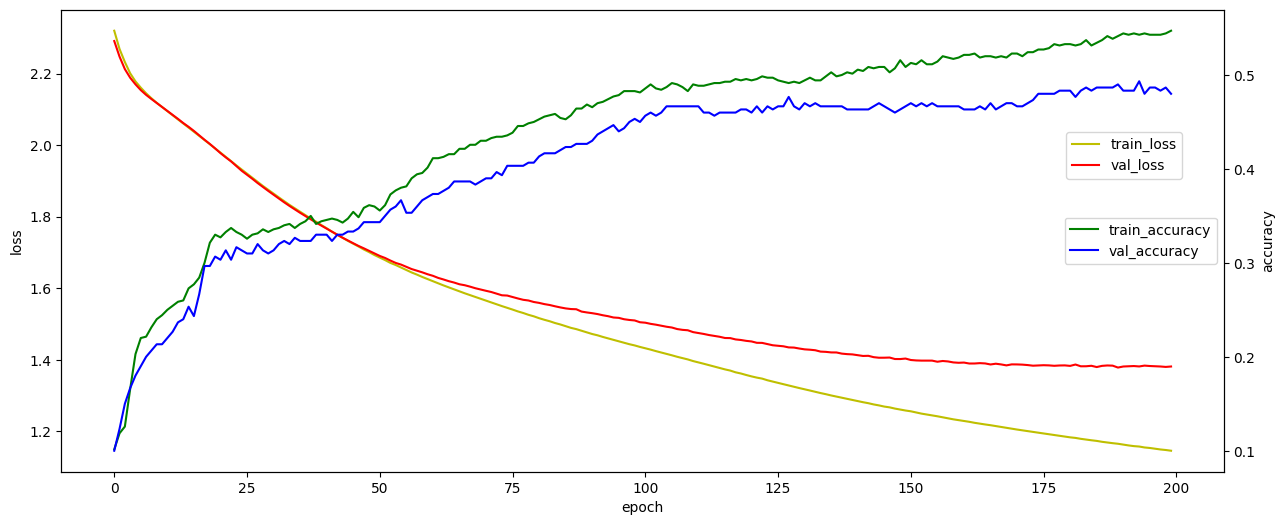

In [80]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [84]:
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

loss : 1.4263769388198853
accuracy : 0.4729999899864197


# 👍위 모델(DNN)의 accuracy 늘리기
- 
-
-
-
-

In [93]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=100,
                epochs=30, 
                # verbose=0
                )

(700, 784) (700, 10) (300, 784) (300, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 2)                 1570      
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_23 (Dense)            (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
7/7 [==============================] - 0s 22ms/step - loss: 2.3032 - accuracy: 0.0957 - val_loss: 2.2877 - val_accuracy: 0.1233
Epoch 2/30
7/7 [==============================] - 0s 5ms/step - loss: 2.2853 - accuracy: 0.1500 - val_loss: 2.26

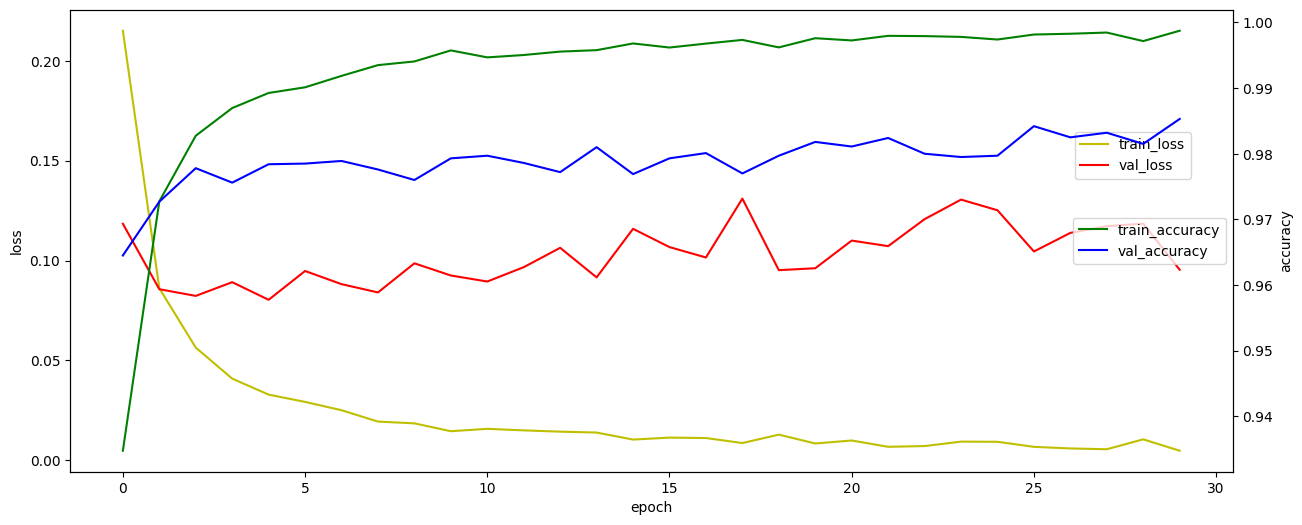

loss : 0.08986269682645798
accuracy : 0.9839000105857849


In [92]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])